# Maser Model Selection — Part 1: Hyperparameter Sweeps

Runs the LR / RF / XGB grids on the X-ray, WISE, and fused planes.
Each sweep ends with a top-3 leaderboard ranked by scenario-mean prec@N, with mse_vs_truth shown alongside.


## 1. Setup

In [12]:
import os
try:
    _ip = str(get_ipython())
except NameError:
    _ip = ""
if 'google.colab' in _ip:
    if not os.path.exists('maser-research'):
        !git clone https://github.com/spragunr/maser-research
    os.chdir('maser-research')

import sys
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
for p in ("src", "../src"):
    ap = os.path.abspath(p)
    if ap not in sys.path:
        sys.path.insert(0, ap)

import itertools
import time
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import synth_data as sd
from maser_data import FEATURES, TARGET   # feature/target names only — no real data is loaded in this notebook

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier

Cloning into 'maser-research'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 67 (delta 26), reused 56 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 1013.96 KiB | 11.79 MiB/s, done.
Resolving deltas: 100% (26/26), done.


In [13]:
# ---- global experiment config: identical for every model & plane ----
SCENARIOS   = ["linear", "wedge", "box", "interaction", "blob"]
STRENGTH    = 3.0
WISE_SIGNAL = 1          # fused-plane default (§4-5); §7 sweeps this knob explicitly
N_AT        = 50
SEEDS       = range(5)
OUTER_SPLITS, OUTER_REPEATS = 5, 3
N_JOBS      = -1        # outer-loop parallelism across (config x scenario x seed); models stay single-threaded

XRAY_FEATS,  XRAY_TGT  = FEATURES["xray"], TARGET["xray"]
WISE_FEATS,  WISE_TGT  = FEATURES["wise"], TARGET["wise"]
FUSED_FEATS, FUSED_TGT = sd.FUSED["columns"], sd.FUSED["target"]

WISE_N  = None                       # WISE catalog is ~7x the X-ray one; set e.g. 1500 to speed §4 (note: changes what prec@N means)
WS_GRID = [0.0, 0.5, 1.0, 1.5, 2.0] # wise_signal values for the §7 sweep (0 = WISE fully redundant with X-ray)

# metric roles: the group's decision is calibration + top-N yield first, AUC demoted to diagnostic
PRIMARY_METRICS    = ["prec_at_n", "mse_vs_truth"]
DIAGNOSTIC_METRICS = ["brier", "pr_auc", "auc"]
METRICS            = PRIMARY_METRICS + DIAGNOSTIC_METRICS
PROMISE_FIELDS     = ["promised_at_n", "delivered_at_n",
                      "promised_total", "actual_total", "true_expected_total"]
HIGHER_BETTER      = {"auc": True, "pr_auc": True, "prec_at_n": True,
                      "brier": False, "mse_vs_truth": False}

for name, f, t in [("xray", XRAY_FEATS, XRAY_TGT), ("wise", WISE_FEATS, WISE_TGT), ("fused", FUSED_FEATS, FUSED_TGT)]:
    print(f"{name} features: {f} | target: {t}")


xray features: ['L_12um_bestfit_1', 'Lob'] | target: is_megamaser_plus
wise features: ['w1w2', 'w2w3'] | target: is_megamaser
fused features: ['L_12um_bestfit_1', 'Lob', 'wise_w1w2', 'wise_w2w3'] | target: is_megamaser_plus


In [14]:
# ---- sanity peek at all three synthetic planes + calibration-reference guard ----
# The generator defines p_obs = p_true * sensitivity. Models learn the OBSERVABLE process,
# so mse_vs_truth (measured against p_true) is only a valid calibration reference while
# p_obs == p_true. Under the current config (no distance/sensitivity noise) they are equal;
# this guard fails loudly if that ever changes, instead of silently mismeasuring calibration.
for sc in SCENARIOS:
    _peek = {
        "xray":  sd.make_dataset("xray", scenario=sc, strength=STRENGTH, seed=0),
        "wise":  sd.make_dataset("wise", scenario=sc, strength=STRENGTH, n=WISE_N, seed=0),
        "fused": sd.make_fused_dataset(scenario=sc, wise_signal=WISE_SIGNAL, strength=STRENGTH, seed=0),
    }
    for _plane, _d in _peek.items():
        assert np.allclose(_d["p_true"], _d["p_obs"]), \
            f"{_plane}/{sc}: p_obs != p_true - mse_vs_truth must be pointed at p_obs before trusting calibration numbers"

for _plane, _tgt in [("xray", XRAY_TGT), ("wise", WISE_TGT), ("fused", FUSED_TGT)]:
    _d = _peek[_plane]
    print(f"{_plane:5s} plane: n={len(_d)}, positives={int(_d[_tgt].sum())} (seed 0, scenario '{SCENARIOS[-1]}')")
_peek["fused"].head()


xray  plane: n=641, positives=71 (seed 0, scenario 'blob')
wise  plane: n=4400, positives=126 (seed 0, scenario 'blob')
fused plane: n=602, positives=44 (seed 0, scenario 'blob')


,L_12um_bestfit_1,Lob,wise_w1w2,wise_w2w3,is_megamaser_plus,Lum_dis,z_true,detected,p_true,p_obs
0,43.668167,42.963785,1.553599,3.780346,0,57.49,0,1,3.829705e-01,3.829705e-01
1,38.918822,38.879149,-0.034738,0.429674,0,14.44,0,1,8.370550e-14,8.370550e-14
2,42.670575,42.168836,0.618087,2.790053,0,107.49,0,1,2.234069e-01,2.234069e-01
3,43.262246,42.998856,0.683569,3.542344,0,147.94,0,1,6.212668e-02,6.212668e-02
4,42.189897,39.749425,0.355399,4.466593,0,31.03,0,1,2.992439e-02,2.992439e-02


## 2. Shared model builders & evaluation harness


In [15]:

def make_lr(features="plain", C=1.0):
    def build():
        steps = [StandardScaler()]
        if features == "interaction":
            steps.append(PolynomialFeatures(2, interaction_only=True, include_bias=False))
        elif features == "quadratic":
            steps.append(PolynomialFeatures(2, interaction_only=False, include_bias=False))
        steps.append(LogisticRegression(C=C, solver="liblinear", max_iter=1000))
        return make_pipeline(*steps)
    return build

def make_rf(n_estimators=150, max_depth=4, min_samples_leaf=5):
    return lambda: RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf, random_state=0, n_jobs=1)

def make_xgb(n_estimators=200, max_depth=3, learning_rate=0.05):
    return lambda: XGBClassifier(
        n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=0, n_jobs=1, tree_method="hist")

In [16]:
# ---- the single synthetic evaluation harness ----
def _eval_one_seed(build, dataset_fn, feats, tgt, seed):
    """All per-repeat metric rows for one (config, scenario, seed). Top-level so
    joblib can ship it to workers; models stay single-threaded (N_JOBS drives the outer loop)."""
    d = dataset_fn(seed)
    X, y, p_true = d[feats].to_numpy(), d[tgt].to_numpy(), d["p_true"].to_numpy()
    rep_rows = []
    for r in range(OUTER_REPEATS):
        skf = StratifiedKFold(OUTER_SPLITS, shuffle=True, random_state=r)
        fold_rows, yp, pp, tp = [], [], [], []
        for tr, te in skf.split(X, y):
            m = build().fit(X[tr], y[tr])
            p = m.predict_proba(X[te])[:, 1]
            fold_rows.append({
                "auc":          roc_auc_score(y[te], p),
                "pr_auc":       average_precision_score(y[te], p),
                "brier":        np.mean((p - y[te]) ** 2),
                "mse_vs_truth": np.mean((p - p_true[te]) ** 2),
            })
            yp.append(y[te]); pp.append(p); tp.append(p_true[te])
        row = pd.DataFrame(fold_rows).mean()
        yp, pp, tp = np.concatenate(yp), np.concatenate(pp), np.concatenate(tp)
        top = np.argsort(-pp)[:N_AT]
        row["prec_at_n"]           = yp[top].mean()
        row["promised_at_n"]       = pp[top].sum()
        row["delivered_at_n"]      = float(yp[top].sum())
        row["promised_total"]      = pp.sum()
        row["actual_total"]        = float(yp.sum())
        row["true_expected_total"] = tp.sum()
        rep_rows.append(row)
    return pd.DataFrame(rep_rows).mean()

def evaluate_synth(build, dataset_fn, feats, tgt):
    """Mean and std over SEEDS of per-repeat metrics. Serial fallback used only
    when called outside run_grid's parallel batch (e.g. the wise_signal sweep)."""
    per_seed = [_eval_one_seed(build, dataset_fn, feats, tgt, s) for s in SEEDS]
    df = pd.DataFrame(per_seed)
    return df.mean().to_dict(), df.std().to_dict()

# dataset factories so the SAME harness serves every synthetic plane
def xray_dataset_fn(scenario):
    return lambda seed: sd.make_dataset("xray", scenario=scenario,
                                        strength=STRENGTH, seed=seed)

def wise_dataset_fn(scenario):
    return lambda seed: sd.make_dataset("wise", scenario=scenario,
                                        strength=STRENGTH, n=WISE_N, seed=seed)

def fused_dataset_fn(scenario):
    return lambda seed: sd.make_fused_dataset(scenario=scenario, wise_signal=WISE_SIGNAL,
                                              strength=STRENGTH, seed=seed)


In [17]:
# ---- sweep runner + display/plot helpers, shared by every sweep and eval ----
def run_grid(grid, dataset_fn_for, feats, tgt, label_col="config"):
    # widest independent axis: one task per (config, scenario, seed), dispatched together
    tasks = [(name, sc, seed) for name in grid for sc in SCENARIOS for seed in SEEDS]
    t0 = time.time()
    per_seed = Parallel(n_jobs=N_JOBS, prefer="processes")(
        delayed(_eval_one_seed)(grid[name], dataset_fn_for(sc), feats, tgt, seed)
        for name, sc, seed in tasks
    )
    # regroup by (config, scenario), then mean/std over seeds to match evaluate_synth's output
    buckets = {}
    for (name, sc, _), r in zip(tasks, per_seed):
        buckets.setdefault((name, sc), []).append(r)
    rows = []
    for name in grid:
        for sc in SCENARIOS:
            df = pd.DataFrame(buckets[(name, sc)])
            mean_out, std_out = df.mean().to_dict(), df.std().to_dict()
            row = {label_col: name, "scenario": sc}
            for m in METRICS + PROMISE_FIELDS:
                row[m], row[f"{m}_std"] = mean_out[m], std_out[m]
            rows.append(row)
    print(f"  {len(grid)} configs x {len(SCENARIOS)} scenarios x {len(list(SEEDS))} seeds "
          f"= {len(tasks)} tasks in {time.time() - t0:.0f}s (n_jobs={N_JOBS})", flush=True)
    return pd.DataFrame(rows)

def sweep_table(sweep, metric, label_col="config"):
    hb = HIGHER_BETTER[metric]
    t = sweep.pivot(index=label_col, columns="scenario", values=metric)[SCENARIOS]
    t["MEAN"]  = t.mean(axis=1)
    t["WORST"] = t.min(axis=1) if hb else t.max(axis=1)
    return t.sort_values("MEAN", ascending=not hb).round(3)

def show_metric(sweep, metric, label_col="config"):
    role = "PRIMARY" if metric in PRIMARY_METRICS else "diagnostic"
    print(f"===== {metric}  ({role}; higher better: {HIGHER_BETTER[metric]}) =====")
    display(sweep_table(sweep, metric, label_col))

def plot_heatmap(sweep, metric, title="", label_col="config"):
    hb = HIGHER_BETTER[metric]
    t = sweep.pivot(index=label_col, columns="scenario", values=metric)[SCENARIOS]
    t = t.loc[t.mean(axis=1).sort_values(ascending=not hb).index]
    fig, ax = plt.subplots(figsize=(7.5, 0.45 * len(t) + 1.5))
    im = ax.imshow(t.values, aspect="auto", cmap="viridis" if hb else "viridis_r")
    ax.set_xticks(range(len(t.columns))); ax.set_xticklabels(t.columns)
    ax.set_yticks(range(len(t.index)));  ax.set_yticklabels(t.index)
    for i in range(t.shape[0]):
        for j in range(t.shape[1]):
            ax.text(j, i, f"{t.values[i, j]:.3f}", ha="center", va="center",
                    color="white", fontsize=8)
    ax.set_title(title or f"{metric} by {label_col} x scenario (best at top)")
    fig.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()

def plot_model_bars(results, metric, title, label_col="model"):
    t = results.pivot(index="scenario", columns=label_col, values=metric).loc[SCENARIOS]
    e = results.pivot(index="scenario", columns=label_col, values=f"{metric}_std").loc[SCENARIOS]
    ax = t.plot.bar(yerr=e, figsize=(9, 4), capsize=2, rot=0)
    ax.set_ylabel(metric); ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.show()

# ---- promised-vs-delivered displays ----
def promise_topn_table(results, label_col="model"):
    """Per scenario: masers promised in the top-N vs masers actually delivered there."""
    p = results.pivot(index=label_col, columns="scenario", values="promised_at_n")[SCENARIOS]
    d = results.pivot(index=label_col, columns="scenario", values="delivered_at_n")[SCENARIOS]
    out = pd.concat({"promised": p, "delivered": d}, axis=1)          # columns: (promised/delivered, scenario)
    out = out.swaplevel(axis=1)                                       # -> (scenario, promised/delivered)
    out = out.reindex(columns=pd.MultiIndex.from_product([SCENARIOS, ["promised", "delivered"]]))
    return out.round(1)

def promise_total_table(results, label_col="model"):
    """Whole-sample promise per scenario, with the actual count and the oracle promise as reference rows."""
    t = results.pivot(index=label_col, columns="scenario", values="promised_total")[SCENARIOS]
    t.loc["ACTUAL masers"]        = results.groupby("scenario")["actual_total"].mean()[SCENARIOS]
    t.loc["ORACLE promise (Σ p_true)"] = results.groupby("scenario")["true_expected_total"].mean()[SCENARIOS]
    return t.round(1)

In [ ]:
# ---- top-3 leaderboard by prec@N, with mse_vs_truth alongside ----
def top3(sweep, label="", k=3, label_col="config"):
    """Rank configs by scenario-mean prec@N (higher better); show mse_vs_truth for the same config."""
    prec = sweep.groupby(label_col)["prec_at_n"].mean()
    mse  = sweep.groupby(label_col)["mse_vs_truth"].mean()
    t = (pd.DataFrame({"model": prec.index, "prec@N": prec.values, "mse": mse.reindex(prec.index).values})
           .sort_values("prec@N", ascending=False)
           .head(k)
           .reset_index(drop=True))
    t.index = range(1, len(t) + 1)
    if label:
        print(f"===== {label} — top {k} by prec@{N_AT} =====")
    display(t.round(3))
    return t


In [18]:
# ---- candidate grids (identical for every plane; each plane picks its own winner) ----
LR_GRID = {
    f"{feat}_C{C}": make_lr(features=feat, C=C)
    for feat, C in itertools.product(["plain", "interaction", "quadratic"],
                                     [0.1, 1.0, 10.0])
}
RF_GRID = {
    f"n{n}_d{d}_l{l}": make_rf(n_estimators=n, max_depth=d, min_samples_leaf=l)
    for n, d, l in itertools.product([150], [3, 4, 6, None], [1, 5, 10])
}
XGB_GRID = {
    f"d{d}_lr{lr}": make_xgb(max_depth=d, learning_rate=lr)
    for d, lr in itertools.product([2, 3, 4], [0.05, 0.1])
}
print(f"grids: LR={len(LR_GRID)}, RF={len(RF_GRID)}, XGB={len(XGB_GRID)} configs")

grids: LR=9, RF=12, XGB=6 configs


## 3. Hyperparameter sweep — X-ray

### 3.1 Logistic regression: feature expansion × C

In [ ]:
lr_sweep_xray = run_grid(LR_GRID, xray_dataset_fn, XRAY_FEATS, XRAY_TGT)

  9 configs x 5 scenarios x 5 seeds = 225 tasks in 42s (n_jobs=-1)


In [ ]:
show_metric(lr_sweep_xray, "prec_at_n")

===== prec_at_n  (PRIMARY; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C1.0,0.311,0.331,0.296,0.333,0.307,0.315,0.296
quadratic_C10.0,0.321,0.320,0.292,0.327,0.296,0.311,0.292
quadratic_C0.1,0.285,0.307,0.301,0.305,0.305,0.301,0.285
interaction_C1.0,0.325,0.315,0.300,0.343,0.068,0.270,0.068
interaction_C10.0,0.324,0.313,0.297,0.341,0.067,0.269,0.067
interaction_C0.1,0.311,0.299,0.321,0.328,0.075,0.267,0.075
plain_C10.0,0.324,0.255,0.249,0.279,0.001,0.222,0.001
plain_C1.0,0.325,0.251,0.251,0.275,0.001,0.221,0.001
plain_C0.1,0.325,0.249,0.245,0.267,0.001,0.218,0.001


In [ ]:
show_metric(lr_sweep_xray, "mse_vs_truth")

===== mse_vs_truth  (PRIMARY; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C1.0,0.002,0.001,0.004,0.002,0.001,0.002,0.004
quadratic_C10.0,0.002,0.002,0.004,0.002,0.001,0.002,0.004
interaction_C1.0,0.002,0.002,0.004,0.001,0.009,0.004,0.009
quadratic_C0.1,0.005,0.003,0.006,0.003,0.002,0.004,0.006
interaction_C10.0,0.002,0.002,0.004,0.002,0.009,0.004,0.009
interaction_C0.1,0.004,0.003,0.006,0.002,0.009,0.005,0.009
plain_C1.0,0.001,0.005,0.005,0.005,0.010,0.005,0.010
plain_C10.0,0.001,0.005,0.005,0.005,0.010,0.005,0.010
plain_C0.1,0.004,0.007,0.007,0.007,0.012,0.007,0.012


In [ ]:
show_metric(lr_sweep_xray, "brier")

===== brier  (diagnostic; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C1.0,0.075,0.073,0.078,0.073,0.071,0.074,0.078
quadratic_C10.0,0.075,0.073,0.079,0.073,0.071,0.074,0.079
interaction_C1.0,0.075,0.074,0.078,0.073,0.080,0.076,0.080
quadratic_C0.1,0.078,0.075,0.080,0.075,0.072,0.076,0.080
interaction_C10.0,0.075,0.074,0.078,0.073,0.080,0.076,0.080
interaction_C0.1,0.078,0.075,0.080,0.075,0.080,0.077,0.080
plain_C1.0,0.075,0.078,0.080,0.078,0.082,0.079,0.082
plain_C10.0,0.075,0.078,0.080,0.078,0.082,0.079,0.082
plain_C0.1,0.078,0.080,0.082,0.081,0.083,0.081,0.083


In [ ]:
show_metric(lr_sweep_xray, "pr_auc")
show_metric(lr_sweep_xray, "auc")

===== pr_auc  (diagnostic; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C10.0,0.324,0.332,0.264,0.330,0.324,0.315,0.264
quadratic_C1.0,0.316,0.330,0.263,0.331,0.330,0.314,0.263
quadratic_C0.1,0.296,0.316,0.283,0.319,0.320,0.307,0.283
interaction_C1.0,0.320,0.324,0.268,0.341,0.185,0.287,0.185
interaction_C10.0,0.321,0.324,0.264,0.341,0.185,0.287,0.185
interaction_C0.1,0.311,0.318,0.277,0.335,0.184,0.285,0.184
plain_C10.0,0.324,0.236,0.226,0.257,0.090,0.226,0.090
plain_C1.0,0.323,0.235,0.226,0.255,0.089,0.226,0.089
plain_C0.1,0.318,0.230,0.223,0.254,0.089,0.223,0.089


===== auc  (diagnostic; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C1.0,0.767,0.801,0.676,0.796,0.841,0.776,0.676
quadratic_C10.0,0.772,0.800,0.672,0.796,0.839,0.776,0.672
quadratic_C0.1,0.715,0.795,0.687,0.785,0.841,0.765,0.687
interaction_C1.0,0.774,0.798,0.676,0.800,0.759,0.762,0.676
interaction_C10.0,0.777,0.798,0.674,0.800,0.759,0.761,0.674
interaction_C0.1,0.736,0.795,0.684,0.799,0.757,0.754,0.684
plain_C10.0,0.778,0.688,0.664,0.679,0.491,0.660,0.491
plain_C1.0,0.778,0.688,0.664,0.679,0.491,0.660,0.491
plain_C0.1,0.773,0.686,0.660,0.678,0.492,0.658,0.492


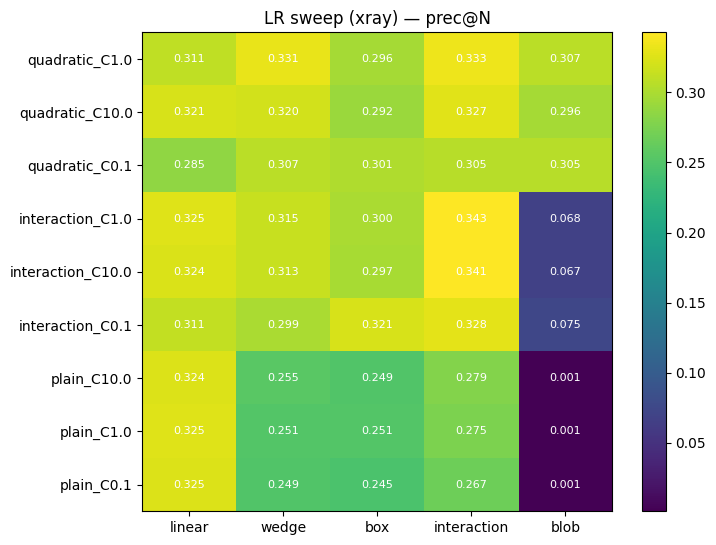

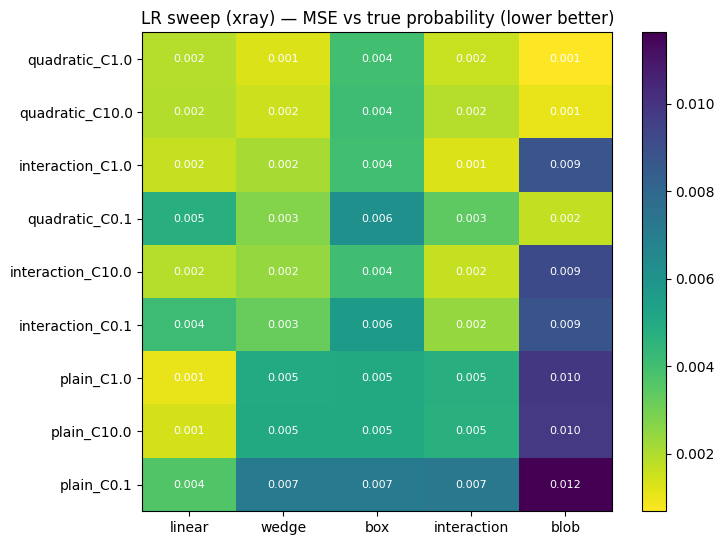

In [ ]:
plot_heatmap(lr_sweep_xray, "prec_at_n", "LR sweep (xray) — prec@N")
plot_heatmap(lr_sweep_xray, "mse_vs_truth", "LR sweep (xray) — MSE vs true probability (lower better)")

In [ ]:
top3(lr_sweep_xray, "LR (xray)")


### 3.2 Random forest: depth × min-leaf (n_estimators fixed at 150 to keep runtime sane)

In [ ]:
rf_sweep_xray = run_grid(RF_GRID, xray_dataset_fn, XRAY_FEATS, XRAY_TGT)

  12 configs x 5 scenarios x 5 seeds = 300 tasks in 1172s (n_jobs=-1)


In [ ]:
show_metric(rf_sweep_xray, "prec_at_n")

===== prec_at_n  (PRIMARY; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
n150_d4_l10,0.267,0.276,0.340,0.296,0.257,0.287,0.257
n150_dNone_l10,0.257,0.267,0.333,0.303,0.268,0.286,0.257
n150_d6_l10,0.257,0.272,0.331,0.301,0.261,0.285,0.257
n150_d4_l5,0.259,0.271,0.339,0.285,0.247,0.280,0.247
n150_d3_l5,0.263,0.257,0.340,0.276,0.253,0.278,0.253
n150_d3_l10,0.261,0.251,0.339,0.269,0.259,0.276,0.251
n150_d4_l1,0.260,0.252,0.319,0.287,0.252,0.274,0.252
n150_dNone_l5,0.255,0.249,0.324,0.271,0.269,0.274,0.249
n150_d6_l5,0.252,0.260,0.327,0.273,0.251,0.273,0.251


In [ ]:
show_metric(rf_sweep_xray, "mse_vs_truth")

===== mse_vs_truth  (PRIMARY; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
n150_d3_l10,0.004,0.002,0.003,0.003,0.002,0.003,0.004
n150_d3_l5,0.004,0.002,0.003,0.003,0.002,0.003,0.004
n150_d3_l1,0.004,0.002,0.003,0.003,0.002,0.003,0.004
n150_d4_l10,0.004,0.002,0.003,0.003,0.002,0.003,0.004
n150_d4_l5,0.004,0.002,0.003,0.003,0.002,0.003,0.004
n150_d4_l1,0.004,0.003,0.004,0.003,0.003,0.003,0.004
n150_d6_l10,0.004,0.003,0.004,0.004,0.003,0.004,0.004
n150_dNone_l10,0.005,0.004,0.004,0.004,0.004,0.004,0.005
n150_d6_l5,0.005,0.004,0.005,0.005,0.004,0.004,0.005


In [ ]:
show_metric(rf_sweep_xray, "brier")

===== brier  (diagnostic; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
n150_d3_l10,0.078,0.074,0.076,0.074,0.073,0.075,0.078
n150_d4_l10,0.078,0.075,0.077,0.074,0.072,0.075,0.078
n150_d3_l5,0.078,0.074,0.076,0.074,0.073,0.075,0.078
n150_d4_l5,0.078,0.075,0.077,0.074,0.073,0.075,0.078
n150_d3_l1,0.078,0.074,0.077,0.074,0.073,0.075,0.078
n150_d4_l1,0.078,0.075,0.077,0.074,0.073,0.075,0.078
n150_d6_l10,0.078,0.076,0.077,0.075,0.073,0.076,0.078
n150_dNone_l10,0.079,0.076,0.077,0.075,0.074,0.076,0.079
n150_d6_l5,0.079,0.077,0.078,0.076,0.074,0.077,0.079


In [ ]:
show_metric(rf_sweep_xray, "pr_auc")
show_metric(rf_sweep_xray, "auc")

===== pr_auc  (diagnostic; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
n150_d4_l10,0.265,0.290,0.289,0.293,0.303,0.288,0.265
n150_d4_l5,0.266,0.289,0.287,0.296,0.297,0.287,0.266
n150_d3_l10,0.267,0.287,0.293,0.290,0.295,0.286,0.267
n150_d3_l5,0.269,0.287,0.292,0.290,0.291,0.286,0.269
n150_d6_l10,0.264,0.283,0.287,0.293,0.298,0.285,0.264
n150_dNone_l10,0.266,0.277,0.288,0.292,0.297,0.284,0.266
n150_d3_l1,0.269,0.281,0.285,0.287,0.294,0.283,0.269
n150_d4_l1,0.267,0.278,0.282,0.295,0.289,0.282,0.267
n150_d6_l5,0.257,0.274,0.277,0.285,0.297,0.278,0.257


===== auc  (diagnostic; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
n150_d3_l10,0.712,0.781,0.671,0.782,0.823,0.754,0.671
n150_d4_l10,0.715,0.776,0.668,0.781,0.824,0.753,0.668
n150_d3_l1,0.711,0.779,0.671,0.781,0.821,0.752,0.671
n150_d3_l5,0.714,0.779,0.666,0.780,0.821,0.752,0.666
n150_d4_l1,0.716,0.773,0.667,0.779,0.820,0.751,0.667
n150_d4_l5,0.715,0.772,0.660,0.779,0.821,0.750,0.660
n150_d6_l10,0.714,0.766,0.661,0.776,0.820,0.748,0.661
n150_dNone_l10,0.712,0.761,0.661,0.774,0.818,0.745,0.661
n150_d6_l5,0.710,0.756,0.653,0.768,0.817,0.741,0.653


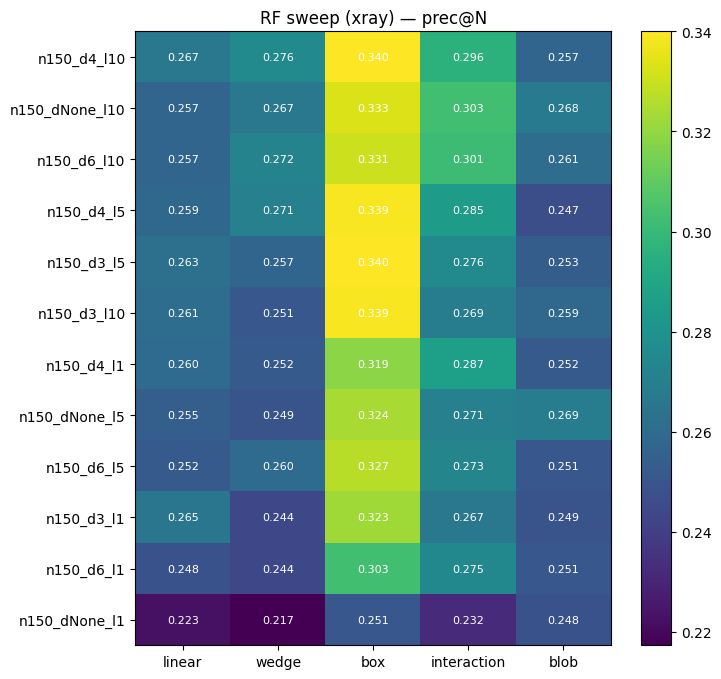

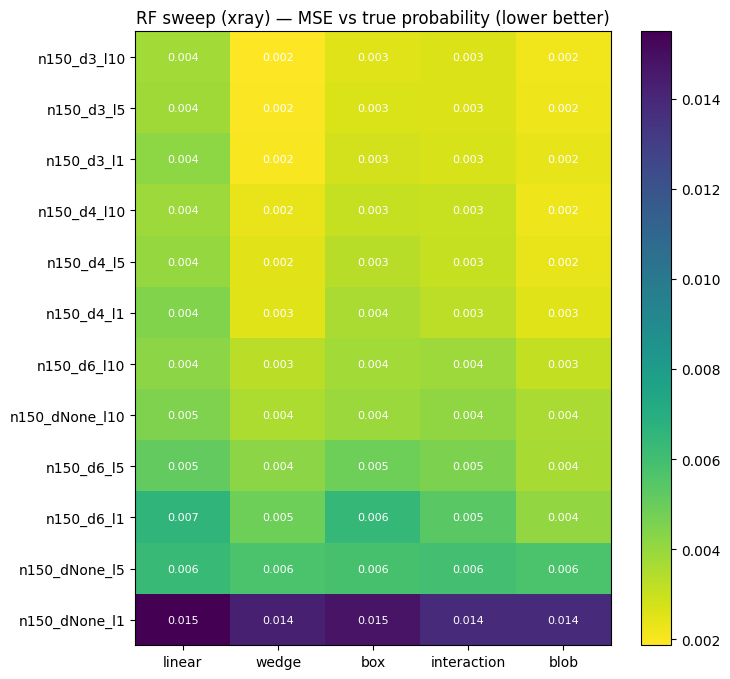

In [ ]:
plot_heatmap(rf_sweep_xray, "prec_at_n", "RF sweep (xray) — prec@N")
plot_heatmap(rf_sweep_xray, "mse_vs_truth", "RF sweep (xray) — MSE vs true probability (lower better)")

In [ ]:
top3(rf_sweep_xray, "RF (xray)")


### 3.3 XGBoost: depth × learning rate

In [ ]:
xgb_sweep_xray = run_grid(XGB_GRID, xray_dataset_fn, XRAY_FEATS, XRAY_TGT)

  6 configs x 5 scenarios x 5 seeds = 150 tasks in 90s (n_jobs=-1)


In [ ]:
show_metric(xgb_sweep_xray, "prec_at_n")

===== prec_at_n  (PRIMARY; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
d2_lr0.05,0.225,0.232,0.268,0.237,0.276,0.248,0.225
d2_lr0.1,0.216,0.227,0.272,0.243,0.280,0.247,0.216
d3_lr0.1,0.211,0.227,0.252,0.253,0.280,0.245,0.211
d3_lr0.05,0.201,0.229,0.257,0.243,0.281,0.242,0.201
d4_lr0.1,0.200,0.216,0.236,0.245,0.269,0.233,0.200
d4_lr0.05,0.184,0.219,0.244,0.243,0.276,0.233,0.184


In [ ]:
show_metric(xgb_sweep_xray, "mse_vs_truth")

===== mse_vs_truth  (PRIMARY; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
d2_lr0.05,0.006,0.005,0.006,0.007,0.005,0.006,0.007
d3_lr0.05,0.008,0.008,0.008,0.009,0.008,0.008,0.009
d2_lr0.1,0.008,0.009,0.009,0.009,0.009,0.009,0.009
d4_lr0.05,0.010,0.010,0.010,0.011,0.010,0.010,0.011
d3_lr0.1,0.011,0.012,0.011,0.013,0.013,0.012,0.013
d4_lr0.1,0.014,0.015,0.014,0.016,0.016,0.015,0.016


In [ ]:
show_metric(xgb_sweep_xray, "brier")

===== brier  (diagnostic; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
d2_lr0.05,0.080,0.078,0.080,0.077,0.074,0.078,0.080
d3_lr0.05,0.083,0.080,0.082,0.079,0.076,0.080,0.083
d2_lr0.1,0.082,0.081,0.082,0.080,0.077,0.081,0.082
d4_lr0.05,0.085,0.083,0.084,0.081,0.078,0.082,0.085
d3_lr0.1,0.086,0.085,0.085,0.083,0.080,0.084,0.086
d4_lr0.1,0.088,0.088,0.088,0.085,0.083,0.086,0.088


In [ ]:
show_metric(xgb_sweep_xray, "pr_auc")
show_metric(xgb_sweep_xray, "auc")

===== pr_auc  (diagnostic; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
d2_lr0.05,0.233,0.262,0.255,0.260,0.310,0.264,0.233
d2_lr0.1,0.230,0.255,0.244,0.258,0.310,0.259,0.230
d3_lr0.05,0.215,0.253,0.244,0.256,0.313,0.256,0.215
d3_lr0.1,0.215,0.241,0.233,0.250,0.305,0.249,0.215
d4_lr0.05,0.198,0.239,0.228,0.247,0.305,0.243,0.198
d4_lr0.1,0.201,0.234,0.221,0.244,0.302,0.240,0.201


===== auc  (diagnostic; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
d2_lr0.05,0.678,0.755,0.639,0.755,0.822,0.730,0.639
d2_lr0.1,0.678,0.746,0.630,0.745,0.815,0.723,0.630
d3_lr0.05,0.660,0.747,0.629,0.747,0.818,0.720,0.629
d3_lr0.1,0.668,0.733,0.622,0.738,0.808,0.714,0.622
d4_lr0.05,0.638,0.732,0.615,0.734,0.811,0.706,0.615
d4_lr0.1,0.648,0.720,0.610,0.724,0.800,0.700,0.610


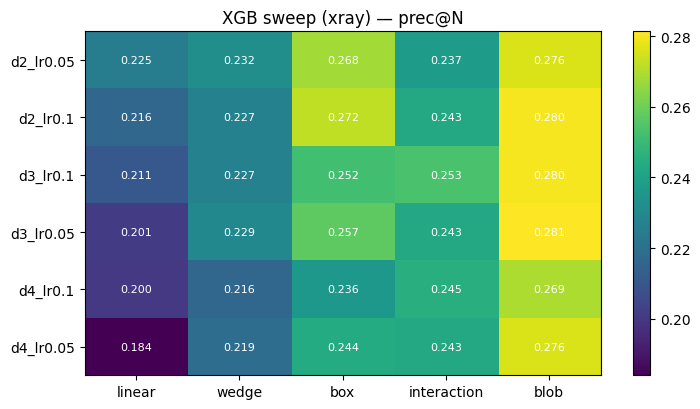

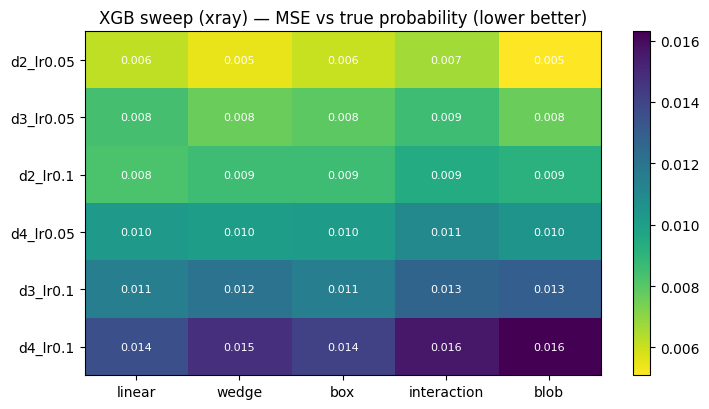

In [ ]:
plot_heatmap(xgb_sweep_xray, "prec_at_n", "XGB sweep (xray) — prec@N")
plot_heatmap(xgb_sweep_xray, "mse_vs_truth", "XGB sweep (xray) — MSE vs true probability (lower better)")

In [ ]:
top3(xgb_sweep_xray, "XGB (xray)")


## 4. Hyperparameter sweeps — WISE

Same grids and protocol as §3. Runtime warning: the WISE catalog is ~7x larger (n≈4400); `WISE_N` in §1 subsamples it if needed.

### 4.1 Logistic regression: feature expansion × C

In [ ]:
lr_sweep_wise = run_grid(LR_GRID, wise_dataset_fn, WISE_FEATS, WISE_TGT)

  9 configs x 5 scenarios x 5 seeds = 225 tasks in 41s (n_jobs=-1)


In [ ]:
show_metric(lr_sweep_wise, "prec_at_n")

===== prec_at_n  (PRIMARY; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C0.1,0.421,0.333,0.093,0.431,0.156,0.287,0.093
quadratic_C1.0,0.416,0.329,0.087,0.433,0.132,0.279,0.087
quadratic_C10.0,0.403,0.329,0.085,0.432,0.133,0.277,0.085
interaction_C10.0,0.404,0.340,0.093,0.415,0.001,0.251,0.001
interaction_C1.0,0.404,0.339,0.093,0.416,0.001,0.251,0.001
interaction_C0.1,0.411,0.329,0.089,0.416,0.000,0.249,0.000
plain_C10.0,0.404,0.319,0.096,0.385,0.000,0.241,0.000
plain_C1.0,0.405,0.309,0.096,0.380,0.000,0.238,0.000
plain_C0.1,0.401,0.285,0.100,0.376,0.000,0.233,0.000


In [ ]:
show_metric(lr_sweep_wise, "mse_vs_truth")

===== mse_vs_truth  (PRIMARY; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C10.0,0.000,0.001,0.001,0.002,0.000,0.001,0.002
quadratic_C1.0,0.000,0.001,0.001,0.002,0.000,0.001,0.002
quadratic_C0.1,0.001,0.001,0.001,0.002,0.000,0.001,0.002
plain_C1.0,0.001,0.001,0.001,0.002,0.001,0.001,0.002
interaction_C0.1,0.001,0.001,0.001,0.002,0.002,0.001,0.002
plain_C0.1,0.001,0.001,0.001,0.003,0.002,0.002,0.003
plain_C10.0,0.001,0.001,0.001,0.002,0.001,0.002,0.002
interaction_C1.0,0.001,0.001,0.001,0.003,0.002,0.002,0.003
interaction_C10.0,0.001,0.001,0.001,0.003,0.002,0.002,0.003


In [ ]:
show_metric(lr_sweep_wise, "brier")

===== brier  (diagnostic; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C10.0,0.023,0.026,0.029,0.023,0.028,0.026,0.029
quadratic_C1.0,0.024,0.026,0.029,0.023,0.028,0.026,0.029
quadratic_C0.1,0.024,0.027,0.029,0.024,0.029,0.026,0.029
interaction_C0.1,0.024,0.027,0.029,0.024,0.030,0.027,0.030
plain_C1.0,0.024,0.027,0.029,0.024,0.030,0.027,0.030
interaction_C1.0,0.024,0.027,0.029,0.024,0.030,0.027,0.030
plain_C10.0,0.025,0.027,0.029,0.024,0.030,0.027,0.030
interaction_C10.0,0.025,0.027,0.029,0.024,0.030,0.027,0.030
plain_C0.1,0.024,0.027,0.029,0.024,0.030,0.027,0.030


In [ ]:
show_metric(lr_sweep_wise, "pr_auc")

===== pr_auc  (diagnostic; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C1.0,0.339,0.243,0.109,0.385,0.135,0.242,0.109
quadratic_C10.0,0.334,0.243,0.108,0.385,0.134,0.241,0.108
quadratic_C0.1,0.333,0.242,0.109,0.379,0.135,0.239,0.109
interaction_C1.0,0.333,0.220,0.104,0.379,0.044,0.216,0.044
interaction_C0.1,0.333,0.220,0.104,0.378,0.044,0.216,0.044
interaction_C10.0,0.330,0.219,0.104,0.379,0.045,0.215,0.045
plain_C10.0,0.338,0.210,0.105,0.357,0.034,0.209,0.034
plain_C1.0,0.337,0.209,0.105,0.353,0.034,0.208,0.034
plain_C0.1,0.328,0.198,0.105,0.328,0.034,0.199,0.034


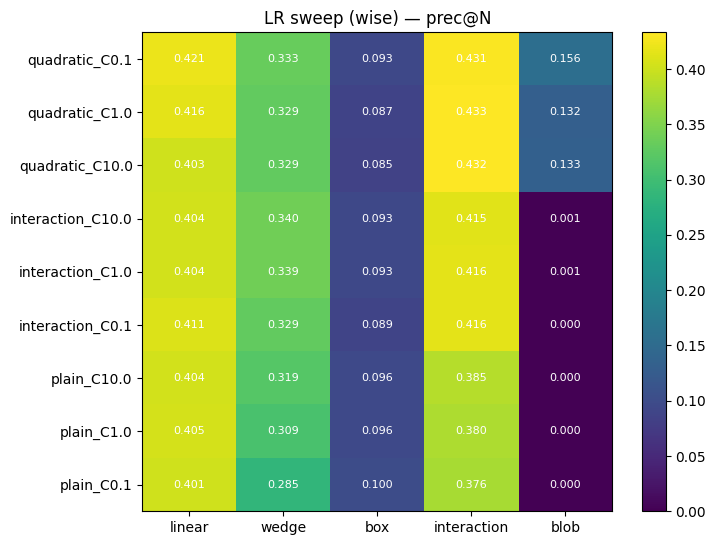

In [ ]:
plot_heatmap(lr_sweep_wise, "prec_at_n", "LR sweep (wise) — prec@N")

In [ ]:
top3(lr_sweep_wise, "LR (wise)")


### 4.2 Random forest: depth × min-leaf

In [ ]:
rf_sweep_wise = run_grid(RF_GRID, wise_dataset_fn, WISE_FEATS, WISE_TGT)

  12 configs x 5 scenarios x 5 seeds = 300 tasks in 2357s (n_jobs=-1)


In [ ]:
show_metric(rf_sweep_wise, "prec_at_n")

===== prec_at_n  (PRIMARY; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
n150_d3_l10,0.384,0.320,0.101,0.385,0.112,0.261,0.101
n150_d4_l10,0.360,0.319,0.091,0.384,0.135,0.258,0.091
n150_d3_l5,0.373,0.317,0.100,0.376,0.100,0.253,0.100
n150_d3_l1,0.372,0.312,0.083,0.379,0.099,0.249,0.083
n150_d4_l5,0.347,0.309,0.096,0.367,0.125,0.249,0.096
n150_d6_l10,0.344,0.303,0.087,0.357,0.123,0.243,0.087
n150_d4_l1,0.340,0.299,0.092,0.375,0.100,0.241,0.092
n150_dNone_l10,0.339,0.291,0.088,0.353,0.132,0.241,0.088
n150_d6_l5,0.303,0.299,0.099,0.351,0.116,0.233,0.099


In [ ]:
show_metric(rf_sweep_wise, "mse_vs_truth")

===== mse_vs_truth  (PRIMARY; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
n150_d4_l10,0.001,0.000,0.000,0.001,0.000,0.001,0.001
n150_d4_l5,0.001,0.000,0.000,0.001,0.000,0.001,0.001
n150_d4_l1,0.001,0.000,0.000,0.001,0.000,0.001,0.001
n150_d6_l10,0.001,0.001,0.000,0.001,0.000,0.001,0.001
n150_d3_l10,0.001,0.001,0.000,0.001,0.001,0.001,0.001
n150_d3_l5,0.001,0.001,0.000,0.001,0.001,0.001,0.001
n150_d3_l1,0.001,0.001,0.000,0.001,0.001,0.001,0.001
n150_d6_l5,0.001,0.001,0.000,0.001,0.000,0.001,0.001
n150_d6_l1,0.001,0.001,0.001,0.001,0.000,0.001,0.001


In [ ]:
show_metric(rf_sweep_wise, "brier")

===== brier  (diagnostic; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
n150_d4_l10,0.024,0.026,0.028,0.023,0.029,0.026,0.029
n150_d4_l5,0.024,0.026,0.028,0.023,0.029,0.026,0.029
n150_d4_l1,0.024,0.026,0.028,0.023,0.029,0.026,0.029
n150_d6_l10,0.024,0.027,0.028,0.023,0.029,0.026,0.029
n150_d3_l10,0.024,0.026,0.028,0.023,0.029,0.026,0.029
n150_d3_l5,0.024,0.026,0.028,0.023,0.029,0.026,0.029
n150_d3_l1,0.024,0.026,0.028,0.023,0.029,0.026,0.029
n150_d6_l5,0.024,0.027,0.028,0.023,0.029,0.026,0.029
n150_d6_l1,0.025,0.027,0.028,0.023,0.029,0.026,0.029


In [ ]:
show_metric(rf_sweep_wise, "pr_auc")

===== pr_auc  (diagnostic; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
n150_d3_l10,0.323,0.237,0.117,0.370,0.112,0.232,0.112
n150_d3_l5,0.322,0.237,0.118,0.370,0.111,0.232,0.111
n150_d4_l10,0.314,0.235,0.113,0.364,0.124,0.230,0.113
n150_d3_l1,0.319,0.238,0.115,0.369,0.107,0.229,0.107
n150_d4_l5,0.312,0.234,0.114,0.367,0.120,0.229,0.114
n150_d4_l1,0.311,0.233,0.114,0.367,0.109,0.227,0.109
n150_d6_l10,0.302,0.228,0.112,0.354,0.124,0.224,0.112
n150_d6_l5,0.294,0.224,0.110,0.351,0.120,0.220,0.110
n150_d6_l1,0.293,0.221,0.110,0.353,0.108,0.217,0.108


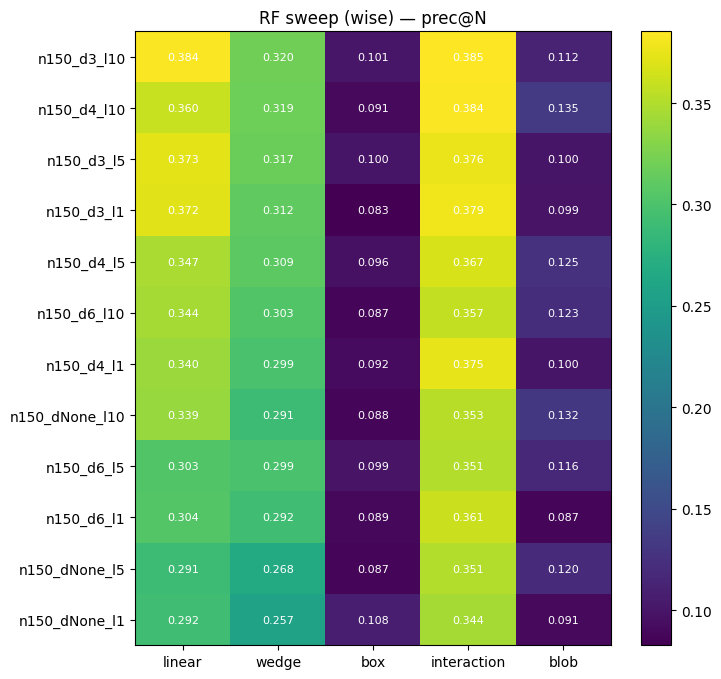

In [ ]:
plot_heatmap(rf_sweep_wise, "prec_at_n", "RF sweep (wise) — prec@N")

In [ ]:
top3(rf_sweep_wise, "RF (wise)")


### 4.3 XGBoost: depth × learning rate

In [ ]:
xgb_sweep_wise = run_grid(XGB_GRID, wise_dataset_fn, WISE_FEATS, WISE_TGT)

  6 configs x 5 scenarios x 5 seeds = 150 tasks in 163s (n_jobs=-1)


In [ ]:
show_metric(xgb_sweep_wise, "prec_at_n")

===== prec_at_n  (PRIMARY; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
d2_lr0.05,0.384,0.280,0.112,0.411,0.149,0.267,0.112
d3_lr0.05,0.380,0.267,0.116,0.412,0.139,0.263,0.116
d2_lr0.1,0.379,0.256,0.108,0.396,0.139,0.255,0.108
d4_lr0.05,0.379,0.247,0.105,0.400,0.135,0.253,0.105
d3_lr0.1,0.365,0.240,0.104,0.415,0.128,0.250,0.104
d4_lr0.1,0.367,0.211,0.100,0.391,0.128,0.239,0.100


In [ ]:
show_metric(xgb_sweep_wise, "mse_vs_truth")

===== mse_vs_truth  (PRIMARY; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
d2_lr0.05,0.001,0.001,0.001,0.001,0.000,0.001,0.001
d3_lr0.05,0.002,0.001,0.001,0.002,0.001,0.001,0.002
d2_lr0.1,0.002,0.001,0.001,0.002,0.001,0.001,0.002
d4_lr0.05,0.002,0.002,0.001,0.002,0.001,0.002,0.002
d3_lr0.1,0.003,0.002,0.002,0.003,0.002,0.002,0.003
d4_lr0.1,0.003,0.003,0.002,0.003,0.002,0.003,0.003


In [ ]:
show_metric(xgb_sweep_wise, "brier")

===== brier  (diagnostic; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
d2_lr0.05,0.024,0.027,0.028,0.023,0.029,0.026,0.029
d3_lr0.05,0.025,0.027,0.029,0.023,0.029,0.027,0.029
d2_lr0.1,0.025,0.027,0.029,0.023,0.029,0.027,0.029
d4_lr0.05,0.025,0.028,0.029,0.024,0.029,0.027,0.029
d3_lr0.1,0.025,0.028,0.029,0.024,0.030,0.027,0.030
d4_lr0.1,0.026,0.029,0.030,0.025,0.030,0.028,0.030


In [ ]:
show_metric(xgb_sweep_wise, "pr_auc")

===== pr_auc  (diagnostic; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
d2_lr0.05,0.319,0.212,0.119,0.369,0.129,0.229,0.119
d2_lr0.1,0.306,0.198,0.114,0.357,0.122,0.219,0.114
d3_lr0.05,0.307,0.197,0.114,0.354,0.123,0.219,0.114
d4_lr0.05,0.295,0.183,0.111,0.342,0.119,0.210,0.111
d3_lr0.1,0.293,0.179,0.109,0.341,0.116,0.208,0.109
d4_lr0.1,0.278,0.166,0.106,0.326,0.111,0.197,0.106


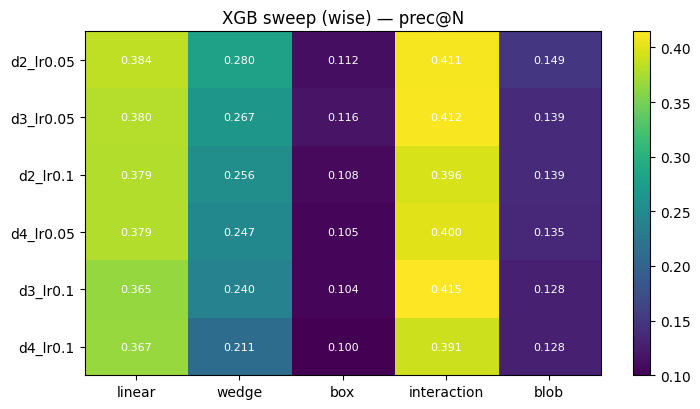

In [ ]:
plot_heatmap(xgb_sweep_wise, "prec_at_n", "XGB sweep (wise) — prec@N")

In [ ]:
top3(xgb_sweep_wise, "XGB (wise)")


## 5. Hyperparameter sweeps — synthetic fused plane (X-ray + WISE)


### 5.1 Logistic regression: feature expansion × C

In [ ]:
lr_sweep_fused = run_grid(LR_GRID, fused_dataset_fn, FUSED_FEATS, FUSED_TGT)

  9 configs x 5 scenarios x 5 seeds = 225 tasks in 25s (n_jobs=-1)


In [ ]:
show_metric(lr_sweep_fused, "prec_at_n")

===== prec_at_n  (PRIMARY; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
interaction_C10.0,0.299,0.272,0.268,0.280,0.296,0.283,0.268
interaction_C1.0,0.292,0.285,0.264,0.273,0.293,0.282,0.264
quadratic_C1.0,0.283,0.260,0.271,0.264,0.311,0.278,0.260
quadratic_C0.1,0.277,0.272,0.264,0.263,0.307,0.277,0.263
quadratic_C10.0,0.288,0.241,0.260,0.252,0.308,0.270,0.241
interaction_C0.1,0.284,0.248,0.271,0.265,0.273,0.268,0.248
plain_C1.0,0.303,0.264,0.281,0.255,0.188,0.258,0.188
plain_C10.0,0.301,0.264,0.275,0.251,0.191,0.256,0.191
plain_C0.1,0.297,0.263,0.265,0.256,0.164,0.249,0.164


In [ ]:
show_metric(lr_sweep_fused, "mse_vs_truth")

===== mse_vs_truth  (PRIMARY; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
quadratic_C1.0,0.005,0.005,0.007,0.005,0.004,0.005,0.007
interaction_C1.0,0.005,0.005,0.006,0.005,0.006,0.005,0.006
interaction_C10.0,0.006,0.005,0.007,0.005,0.006,0.006,0.007
quadratic_C10.0,0.006,0.006,0.007,0.005,0.005,0.006,0.007
plain_C1.0,0.004,0.006,0.006,0.007,0.012,0.007,0.012
plain_C10.0,0.005,0.006,0.006,0.007,0.012,0.007,0.012
quadratic_C0.1,0.010,0.008,0.011,0.008,0.007,0.009,0.011
interaction_C0.1,0.009,0.008,0.010,0.008,0.009,0.009,0.010
plain_C0.1,0.007,0.008,0.009,0.009,0.013,0.009,0.013


In [ ]:
show_metric(lr_sweep_fused, "brier")

===== brier  (diagnostic; higher better: False) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
interaction_C1.0,0.069,0.068,0.068,0.066,0.068,0.068,0.069
quadratic_C1.0,0.069,0.068,0.069,0.067,0.067,0.068,0.069
interaction_C10.0,0.070,0.069,0.069,0.067,0.069,0.069,0.070
plain_C1.0,0.068,0.069,0.068,0.067,0.074,0.069,0.074
quadratic_C0.1,0.072,0.069,0.070,0.067,0.068,0.069,0.072
quadratic_C10.0,0.070,0.070,0.070,0.069,0.069,0.069,0.070
interaction_C0.1,0.071,0.069,0.070,0.067,0.070,0.070,0.071
plain_C10.0,0.069,0.070,0.068,0.068,0.074,0.070,0.074
plain_C0.1,0.069,0.070,0.069,0.069,0.075,0.070,0.075


In [ ]:
show_metric(lr_sweep_fused, "pr_auc")
show_metric(lr_sweep_fused, "auc")

===== pr_auc  (diagnostic; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
interaction_C1.0,0.306,0.314,0.287,0.305,0.330,0.308,0.287
interaction_C10.0,0.309,0.313,0.285,0.301,0.331,0.308,0.285
quadratic_C1.0,0.306,0.300,0.279,0.292,0.358,0.307,0.279
quadratic_C10.0,0.310,0.299,0.279,0.288,0.346,0.304,0.279
interaction_C0.1,0.294,0.301,0.286,0.300,0.306,0.297,0.286
quadratic_C0.1,0.278,0.285,0.272,0.285,0.338,0.292,0.272
plain_C1.0,0.317,0.289,0.299,0.289,0.223,0.283,0.223
plain_C10.0,0.314,0.290,0.297,0.286,0.224,0.282,0.224
plain_C0.1,0.320,0.287,0.295,0.287,0.209,0.280,0.209


===== auc  (diagnostic; higher better: True) =====


scenario,linear,wedge,box,interaction,blob,MEAN,WORST
config,,,,,,,
interaction_C10.0,0.828,0.831,0.803,0.829,0.849,0.828,0.803
interaction_C1.0,0.825,0.831,0.796,0.828,0.850,0.826,0.796
quadratic_C10.0,0.825,0.818,0.786,0.815,0.848,0.819,0.786
quadratic_C1.0,0.818,0.820,0.782,0.816,0.851,0.818,0.782
plain_C1.0,0.838,0.821,0.810,0.803,0.759,0.806,0.759
plain_C10.0,0.837,0.821,0.809,0.801,0.760,0.806,0.760
plain_C0.1,0.835,0.817,0.799,0.799,0.746,0.799,0.746
interaction_C0.1,0.773,0.801,0.742,0.800,0.826,0.788,0.742
quadratic_C0.1,0.745,0.787,0.720,0.783,0.831,0.773,0.720


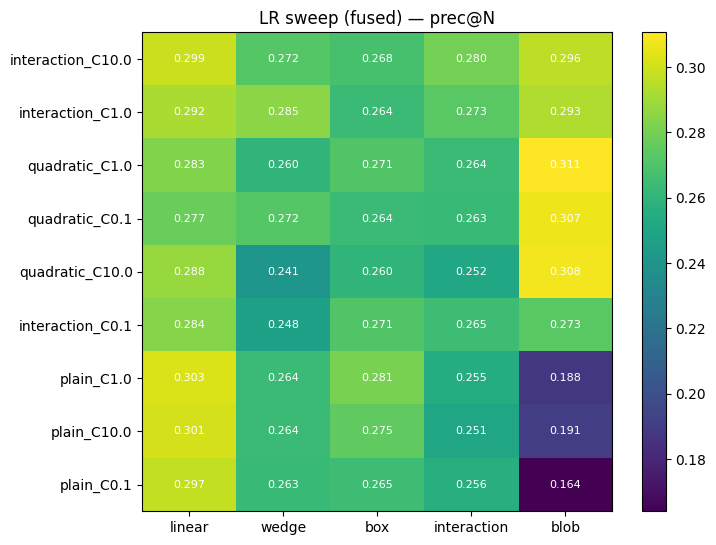

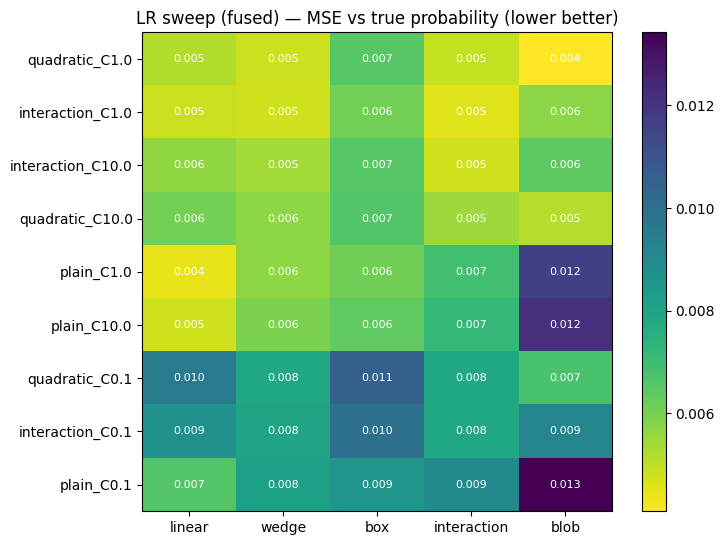

In [ ]:
plot_heatmap(lr_sweep_fused, "prec_at_n", "LR sweep (fused) — prec@N")
plot_heatmap(lr_sweep_fused, "mse_vs_truth", "LR sweep (fused) — MSE vs true probability (lower better)")

In [ ]:
top3(lr_sweep_fused, "LR (fused)")


### 5.2 Random forest: depth × min-leaf

In [ ]:
rf_sweep_fused = run_grid(RF_GRID, fused_dataset_fn, FUSED_FEATS, FUSED_TGT)

In [ ]:
show_metric(rf_sweep_fused, "prec_at_n")

In [ ]:
show_metric(rf_sweep_fused, "mse_vs_truth")

In [ ]:
show_metric(rf_sweep_fused, "brier")

In [ ]:
show_metric(rf_sweep_fused, "pr_auc")
show_metric(rf_sweep_fused, "auc")

In [ ]:
plot_heatmap(rf_sweep_fused, "prec_at_n", "RF sweep (fused) — prec@N")
plot_heatmap(rf_sweep_fused, "mse_vs_truth", "RF sweep (fused) — MSE vs true probability (lower better)")

In [ ]:
top3(rf_sweep_fused, "RF (fused)")


### 5.3 XGBoost: depth × learning rate

In [ ]:
xgb_sweep_fused = run_grid(XGB_GRID, fused_dataset_fn, FUSED_FEATS, FUSED_TGT)

In [ ]:
show_metric(xgb_sweep_fused, "prec_at_n")

In [ ]:
show_metric(xgb_sweep_fused, "mse_vs_truth")

In [ ]:
show_metric(xgb_sweep_fused, "brier")

In [ ]:
show_metric(xgb_sweep_fused, "pr_auc")
show_metric(xgb_sweep_fused, "auc")

In [ ]:
plot_heatmap(xgb_sweep_fused, "prec_at_n", "XGB sweep (fused) — prec@N")
plot_heatmap(xgb_sweep_fused, "mse_vs_truth", "XGB sweep (fused) — MSE vs true probability (lower better)")

In [ ]:
top3(xgb_sweep_fused, "XGB (fused)")
